# 🧠 Brain Tumor MRI Classification Using Deep Learning

## 📚 1. Import Library

Pada tahap ini dilakukan import seluruh library yang dibutuhkan selama proses pengembangan model Deep Learning. Library yang digunakan meliputi TensorFlow untuk membangun model CNN dan EfficientNetB0, NumPy dan Pandas untuk pengolahan data, Matplotlib dan Seaborn untuk visualisasi, serta Scikit-Learn untuk evaluasi model.

Selain itu, notebook akan menampilkan informasi versi TensorFlow dan status GPU untuk memastikan proses pelatihan dapat berjalan secara optimal.

In [ ]:
# ==========================================================
# IMPORT LIBRARY
# ==========================================================

# Jika TensorFlow belum tersedia, jalankan:
# !pip install -q tensorflow

import os
import zipfile
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

from google.colab import files

from tensorflow.keras.preprocessing import image_dataset_from_directory

warnings.filterwarnings("ignore")

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("="*60)
print("Brain Tumor MRI Classification Using Deep Learning")
print("="*60)
print(f"TensorFlow Version : {tf.__version__}")

gpu = tf.config.list_physical_devices('GPU')

if gpu:
    print("GPU Status : Available")
    print(gpu)
else:
    print("GPU Status : Not Available")

print("="*60)

Brain Tumor MRI Classification Using Deep Learning
TensorFlow Version : 2.20.0
GPU Status : Available
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# 📂 2. Data Collection

Tahap ini bertujuan untuk mengunggah dataset Brain Tumor MRI dalam format **ZIP** ke Google Colab. Setelah dataset berhasil diunggah, sistem akan melakukan ekstraksi secara otomatis sehingga struktur folder **Training** dan **Testing** dapat digunakan pada proses pelatihan model.

Dataset yang digunakan memiliki empat kelas, yaitu:

- Glioma
- Meningioma
- Pituitary
- No Tumor

In [ ]:
# ==========================================================
# UPLOAD DATASET
# ==========================================================

print("="*60)
print("Upload Brain Tumor Dataset (.zip)")
print("="*60)

uploaded = files.upload()

zip_name = next(iter(uploaded))

print(f"\nDataset berhasil diupload : {zip_name}")

Upload Brain Tumor Dataset (.zip)


Saving archive (7).zip to archive (7).zip

Dataset berhasil diupload : archive (7).zip


# 📦 3. Extract Dataset

Dataset yang telah diunggah akan diekstrak secara otomatis ke dalam direktori kerja Google Colab. Tahap ini memastikan seluruh folder dan citra dapat diakses pada proses selanjutnya.

In [ ]:
# ==========================================================
# EXTRACT DATASET
# ==========================================================

DATASET_PATH = "/content/dataset"

os.makedirs(DATASET_PATH, exist_ok=True)

with zipfile.ZipFile(zip_name, 'r') as zip_ref:
    zip_ref.extractall(DATASET_PATH)

print("="*60)
print("Dataset berhasil diekstrak.")
print("="*60)

for item in os.listdir(DATASET_PATH):
    print(item)

Dataset berhasil diekstrak.
Training
Testing


# ⚙️ 4. Configuration

Pada tahap ini ditentukan parameter utama yang digunakan selama proses pelatihan model, seperti ukuran citra, ukuran batch, jumlah epoch, serta lokasi folder dataset.

In [ ]:
# ==========================================================
# CONFIGURATION
# ==========================================================

IMAGE_SIZE = (224,224)

BATCH_SIZE = 32

EPOCHS = 20

SEED = 42

TRAIN_DIR = os.path.join(DATASET_PATH, "Training")

TEST_DIR = os.path.join(DATASET_PATH, "Testing")

print("="*60)
print("Configuration")
print("="*60)

print(f"Image Size : {IMAGE_SIZE}")
print(f"Batch Size : {BATCH_SIZE}")
print(f"Epoch      : {EPOCHS}")

print("\nTraining Directory")
print(TRAIN_DIR)

print("\nTesting Directory")
print(TEST_DIR)

Configuration
Image Size : (224, 224)
Batch Size : 32
Epoch      : 20

Training Directory
/content/dataset/Training

Testing Directory
/content/dataset/Testing


# 📥 5. Load Dataset

Dataset dimuat menggunakan fungsi `image_dataset_from_directory()`. Data pelatihan akan dibagi menjadi **Training** dan **Validation**, sedangkan folder **Testing** digunakan untuk evaluasi akhir model.

Pada tahap ini juga akan ditampilkan informasi jumlah kelas serta nama setiap kelas yang terdapat pada dataset.

In [ ]:
# ==========================================================
# LOAD DATASET
# ==========================================================

train_dataset = image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

validation_dataset = image_dataset_from_directory(
    TRAIN_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

test_dataset = image_dataset_from_directory(
    TEST_DIR,
    shuffle=False,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_dataset.class_names

print("="*60)
print("Class Information")
print("="*60)

print(f"Total Class : {len(class_names)}")

print("\nClass Name :")

for i, cls in enumerate(class_names, start=1):
    print(f"{i}. {cls}")

Found 5600 files belonging to 4 classes.
Using 4480 files for training.
Found 5600 files belonging to 4 classes.
Using 1120 files for validation.
Found 1600 files belonging to 4 classes.
Class Information
Total Class : 4

Class Name :
1. glioma
2. meningioma
3. notumor
4. pituitary


# 📋 6. Dataset Overview

Tahap ini bertujuan untuk menampilkan ringkasan dataset yang akan digunakan pada proses pelatihan. Informasi yang ditampilkan meliputi jumlah gambar pada setiap kelas untuk data pelatihan dan data pengujian sehingga distribusi dataset dapat diketahui sebelum proses training dilakukan.

In [ ]:
# ==========================================================
# DATASET OVERVIEW
# ==========================================================

import os
import pandas as pd

train_counts = {}
test_counts = {}

for cls in sorted(os.listdir(TRAIN_DIR)):
    cls_path = os.path.join(TRAIN_DIR, cls)

    if os.path.isdir(cls_path):
        train_counts[cls] = len([
            f for f in os.listdir(cls_path)
            if f.lower().endswith((".jpg",".jpeg",".png"))
        ])

for cls in sorted(os.listdir(TEST_DIR)):
    cls_path = os.path.join(TEST_DIR, cls)

    if os.path.isdir(cls_path):
        test_counts[cls] = len([
            f for f in os.listdir(cls_path)
            if f.lower().endswith((".jpg",".jpeg",".png"))
        ])

dataset_info = pd.DataFrame({
    "Class": train_counts.keys(),
    "Training": train_counts.values(),
    "Testing": test_counts.values()
})

dataset_info["Total"] = dataset_info["Training"] + dataset_info["Testing"]

print("="*65)
print("📊 DATASET OVERVIEW")
print("="*65)

display(dataset_info)

print()

print(f"Total Training Images : {dataset_info['Training'].sum():,}")
print(f"Total Testing Images  : {dataset_info['Testing'].sum():,}")
print(f"Grand Total Images    : {dataset_info['Total'].sum():,}")

print("="*65)

📊 DATASET OVERVIEW


,Class,Training,Testing,Total
0,glioma,1400,400,1800
1,meningioma,1400,400,1800
2,notumor,1400,400,1800
3,pituitary,1400,400,1800



Total Training Images : 5,600
Total Testing Images  : 1,600
Grand Total Images    : 7,200


# 📊 7. Distribusi Dataset

Visualisasi berikut menunjukkan distribusi jumlah gambar pada setiap kelas. Distribusi yang seimbang akan membantu model belajar secara lebih optimal dan mengurangi potensi bias terhadap kelas tertentu.

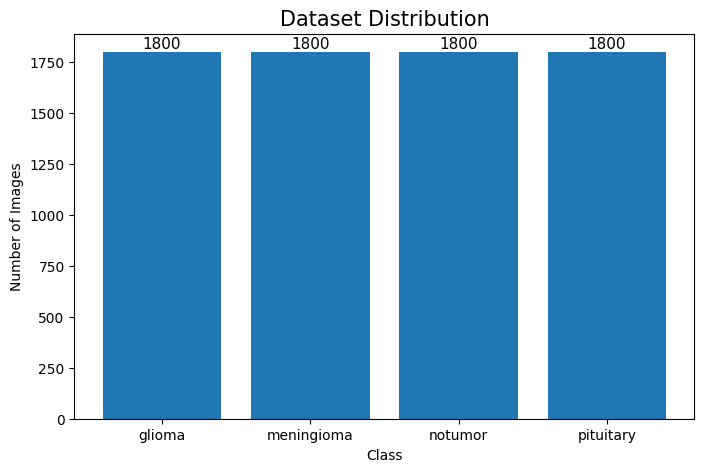

In [ ]:
# ==========================================================
# BAR CHART DISTRIBUTION
# ==========================================================

plt.figure(figsize=(8,5))

plt.bar(
    dataset_info["Class"],
    dataset_info["Total"]
)

plt.title("Dataset Distribution", fontsize=15)

plt.xlabel("Class")

plt.ylabel("Number of Images")

for i,v in enumerate(dataset_info["Total"]):
    plt.text(i,v+20,str(v),ha='center',fontsize=11)

plt.show()

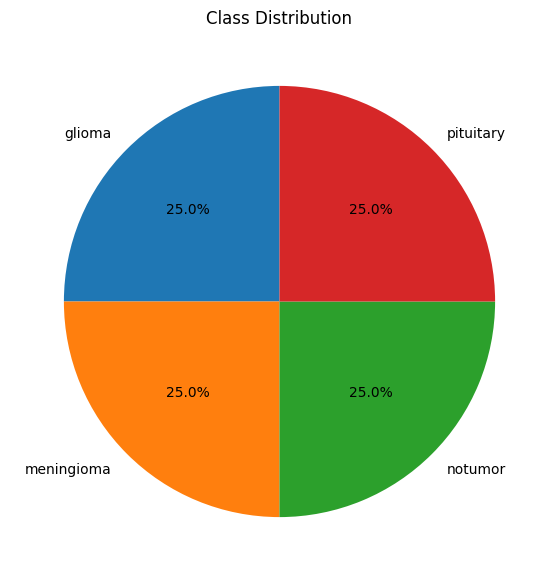

In [ ]:
# ==========================================================
# PIE CHART
# ==========================================================

plt.figure(figsize=(7,7))

plt.pie(
    dataset_info["Total"],
    labels=dataset_info["Class"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Class Distribution")

plt.show()

# 🖼️ 8. Sample Images

Visualisasi berikut menampilkan beberapa contoh citra MRI dari masing-masing kelas. Tahap ini bertujuan untuk memahami karakteristik visual dari setiap kategori sebelum model dilatih.

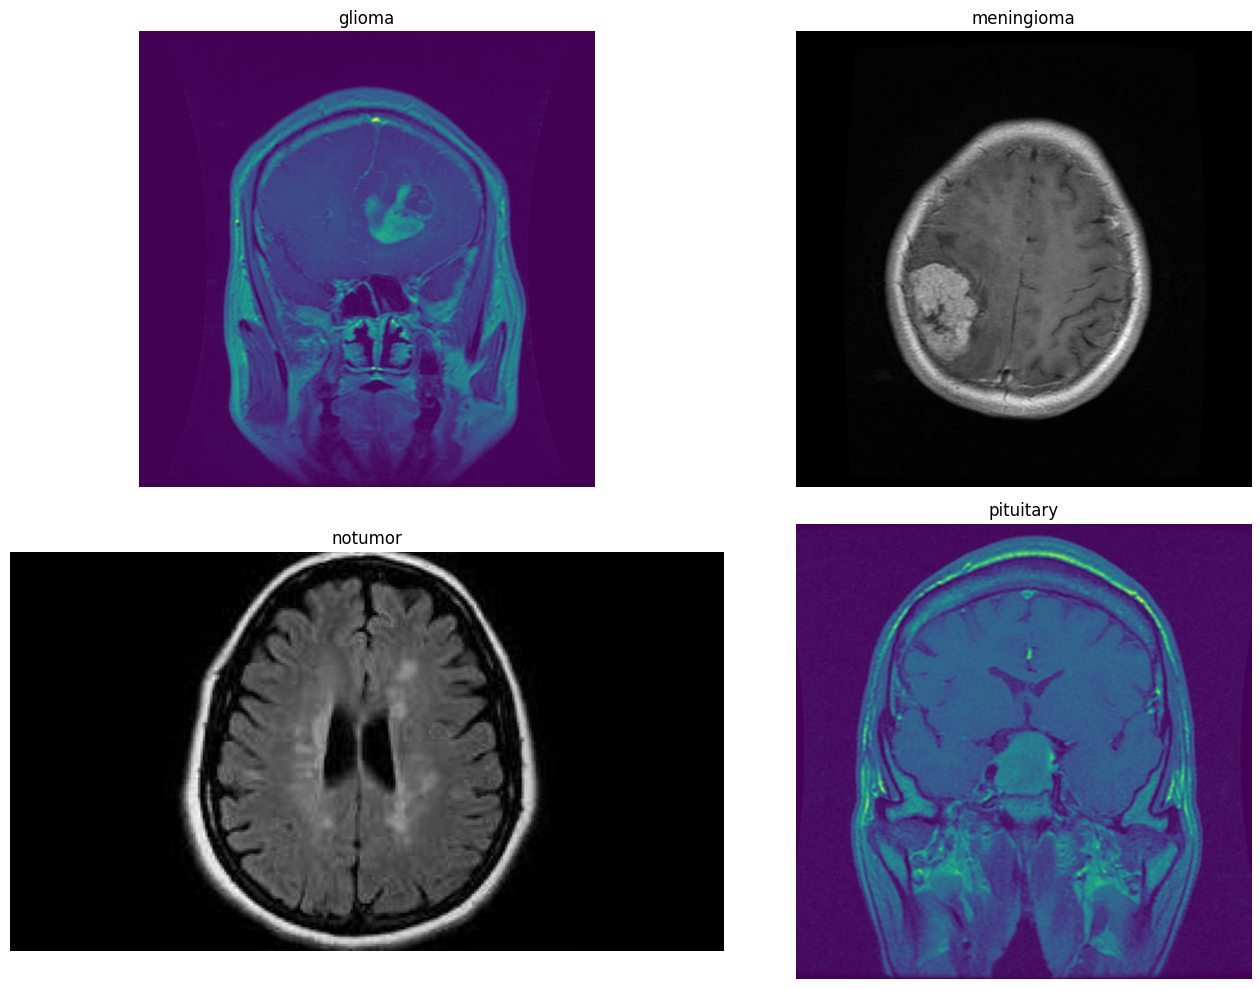

In [ ]:
# ==========================================================
# SAMPLE IMAGES
# ==========================================================

import matplotlib.pyplot as plt
import matplotlib.image as mpimg

plt.figure(figsize=(14,10))

for i, cls in enumerate(class_names):

    folder = os.path.join(TRAIN_DIR, cls)

    image_name = random.choice(os.listdir(folder))

    image_path = os.path.join(folder,image_name)

    img = mpimg.imread(image_path)

    plt.subplot(2,2,i+1)

    plt.imshow(img)

    plt.title(cls)

    plt.axis("off")

plt.tight_layout()

plt.show()

# 🛠️ 9. Data Preparation

Pada tahap ini dilakukan preprocessing data berupa normalisasi citra dan data augmentation untuk meningkatkan kemampuan generalisasi model selama proses pelatihan.

In [ ]:
# ==========================================================
# DATA PREPARATION
# ==========================================================

AUTOTUNE = tf.data.AUTOTUNE

normalization_layer = tf.keras.layers.Rescaling(1./255)

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1)
])

train_dataset = train_dataset.map(
    lambda x, y: (normalization_layer(data_augmentation(x)), y),
    num_parallel_calls=AUTOTUNE
)

validation_dataset = validation_dataset.map(
    lambda x, y: (normalization_layer(x), y),
    num_parallel_calls=AUTOTUNE
)

test_dataset = test_dataset.map(
    lambda x, y: (normalization_layer(x), y),
    num_parallel_calls=AUTOTUNE
)

train_dataset = train_dataset.prefetch(AUTOTUNE)
validation_dataset = validation_dataset.prefetch(AUTOTUNE)
test_dataset = test_dataset.prefetch(AUTOTUNE)

print("✅ Data preparation selesai.")

✅ Data preparation selesai.


# 🖼️ 10. Data Augmentation Preview

Visualisasi hasil augmentasi untuk memastikan proses preprocessing berjalan dengan baik.

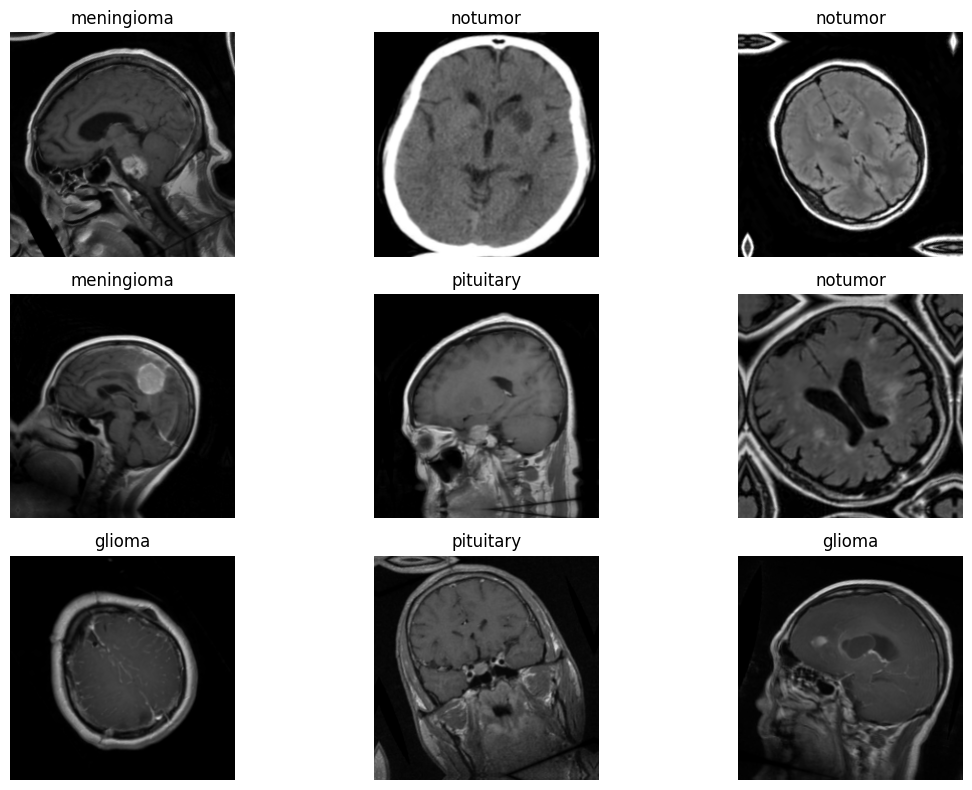

In [ ]:
# ==========================================================
# AUGMENTATION PREVIEW
# ==========================================================

plt.figure(figsize=(12,8))

for images, labels in train_dataset.take(1):

    for i in range(9):

        ax = plt.subplot(3,3,i+1)

        plt.imshow(images[i])

        plt.title(class_names[labels[i]])

        plt.axis("off")

plt.tight_layout()

plt.show()

# 🧠 11. Modeling - Custom CNN

Model pertama yang digunakan adalah Convolutional Neural Network (CNN) sebagai model baseline untuk klasifikasi citra MRI Brain Tumor.

In [ ]:
# ==========================================================
# BUILD CUSTOM CNN
# ==========================================================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    BatchNormalization,
    Flatten,
    Dense,
    Dropout
)

cnn_model = Sequential([

    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(256, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(512, activation='relu'),
    Dropout(0.5),

    Dense(256, activation='relu'),
    Dropout(0.3),

    Dense(len(class_names), activation='softmax')

])

cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    18,874,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,397,572 (74.00 MB)

 Trainable params: 19,396,612 (73.99 MB)

 Non-trainable params: 960 (3.75 KB)

# ⚙️ 12. Compile Model

Mengatur optimizer, loss function, dan evaluation metrics.

In [ ]:
# ==========================================================
# COMPILE MODEL
# ==========================================================

cnn_model.compile(

    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),

    loss='sparse_categorical_crossentropy',

    metrics=['accuracy']

)

# 🚀 13. Train Custom CNN

Melakukan proses pelatihan model CNN.

In [ ]:
# ==========================================================
# CALLBACK
# ==========================================================

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=3
)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_cnn.keras",
    monitor="val_accuracy",
    save_best_only=True
)

In [ ]:
# ==========================================================
# TRAIN CNN
# ==========================================================

history_cnn = cnn_model.fit(

    train_dataset,

    validation_data=validation_dataset,

    epochs=EPOCHS,

    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint
    ]

)

Epoch 1/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 76s 425ms/step - accuracy: 0.5842 - loss: 1.5194 - val_accuracy: 0.3107 - val_loss: 4.0326 - learning_rate: 1.0000e-04
Epoch 2/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 55s 392ms/step - accuracy: 0.6603 - loss: 0.9114 - val_accuracy: 0.3580 - val_loss: 3.0759 - learning_rate: 1.0000e-04
Epoch 3/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 83s 399ms/step - accuracy: 0.7033 - loss: 0.7855 - val_accuracy: 0.4723 - val_loss: 1.5019 - learning_rate: 1.0000e-04
Epoch 4/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 57s 402ms/step - accuracy: 0.7431 - loss: 0.6880 - val_accuracy: 0.7464 - val_loss: 0.6277 - learning_rate: 1.0000e-04
Epoch 5/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 81s 396ms/step - accuracy: 0.7435 - loss: 0.6588 - val_accuracy: 0.8071 - val_loss: 0.4565 - learning_rate: 1.0000e-04
Epoch 6/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 56s 397ms/step - accuracy: 0.7596 - loss: 0.6409 - val_accuracy: 0.8304 - val_loss: 0.4552 - learning_rate: 1.0000e-04
Epoch 7/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 81s 38

# 📈 14. Training Result

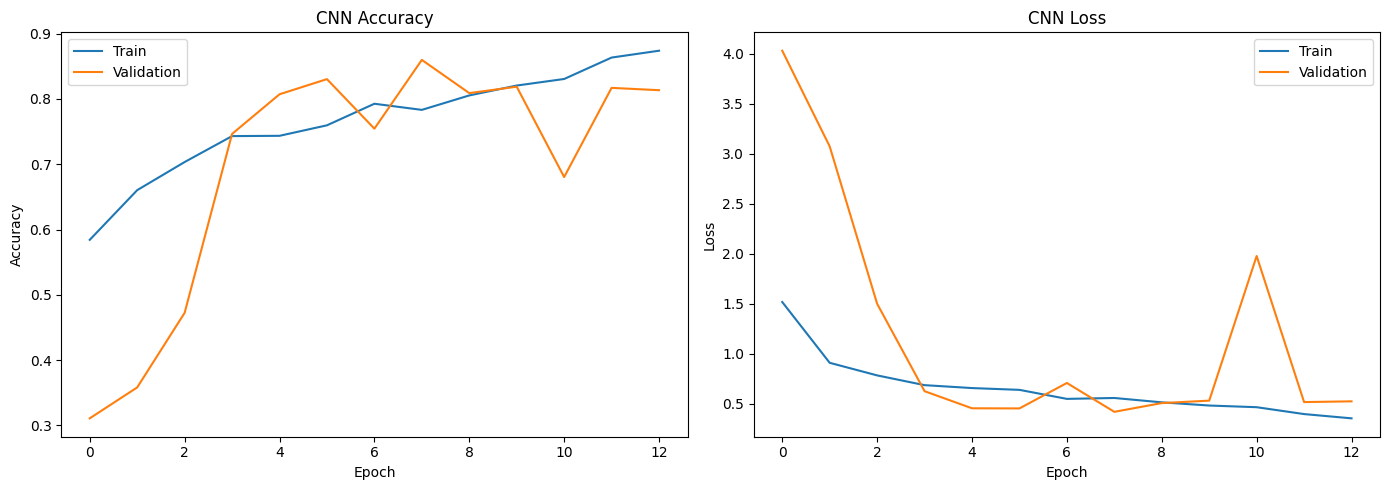

In [ ]:
# ==========================================================
# ACCURACY & LOSS
# ==========================================================

plt.figure(figsize=(14,5))

plt.subplot(1,2,1)

plt.plot(history_cnn.history["accuracy"], label="Train")
plt.plot(history_cnn.history["val_accuracy"], label="Validation")

plt.title("CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1,2,2)

plt.plot(history_cnn.history["loss"], label="Train")
plt.plot(history_cnn.history["val_loss"], label="Validation")

plt.title("CNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()

plt.show()

# 📊 15. Evaluation - Custom CNN

Tahap ini dilakukan untuk mengevaluasi performa model CNN menggunakan data testing.

In [ ]:
# ==========================================================
# PREDICTION
# ==========================================================

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

y_true = np.concatenate([y for x, y in test_dataset], axis=0)

y_prob = cnn_model.predict(test_dataset)

y_pred = np.argmax(y_prob, axis=1)

50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step


In [ ]:
# ==========================================================
# ACCURACY
# ==========================================================

cnn_accuracy = accuracy_score(y_true, y_pred)

print("="*60)
print("CNN Accuracy :", round(cnn_accuracy*100,2),"%")
print("="*60)

CNN Accuracy : 76.06 %


In [ ]:
# ==========================================================
# CLASSIFICATION REPORT
# ==========================================================

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

      glioma       0.82      0.65      0.73       400
  meningioma       0.76      0.43      0.55       400
     notumor       0.66      0.99      0.79       400
   pituitary       0.86      0.97      0.91       400

    accuracy                           0.76      1600
   macro avg       0.77      0.76      0.74      1600
weighted avg       0.77      0.76      0.74      1600



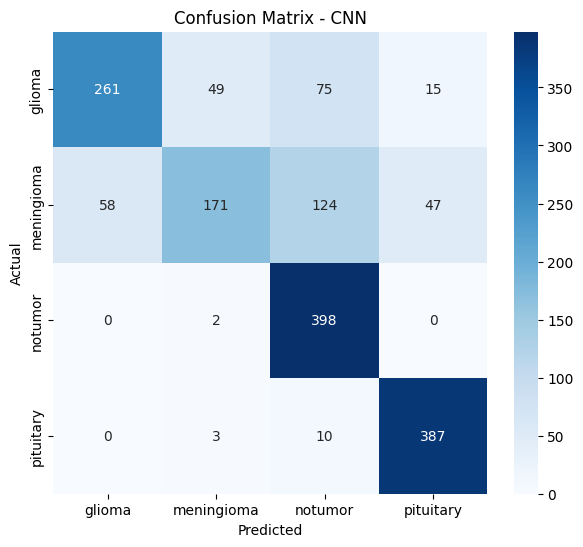

In [ ]:
# ==========================================================
# CONFUSION MATRIX
# ==========================================================

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix - CNN")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [ ]:
# ==========================================================
# METRICS
# ==========================================================

from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

cnn_precision = precision_score(
    y_true,
    y_pred,
    average="weighted"
)

cnn_recall = recall_score(
    y_true,
    y_pred,
    average="weighted"
)

cnn_f1 = f1_score(
    y_true,
    y_pred,
    average="weighted"
)

cnn_result = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ],

    "Score":[
        cnn_accuracy,
        cnn_precision,
        cnn_recall,
        cnn_f1
    ]

})

display(cnn_result)

,Metric,Score
0,Accuracy,0.760625
1,Precision,0.773945
2,Recall,0.760625
3,F1-Score,0.743834


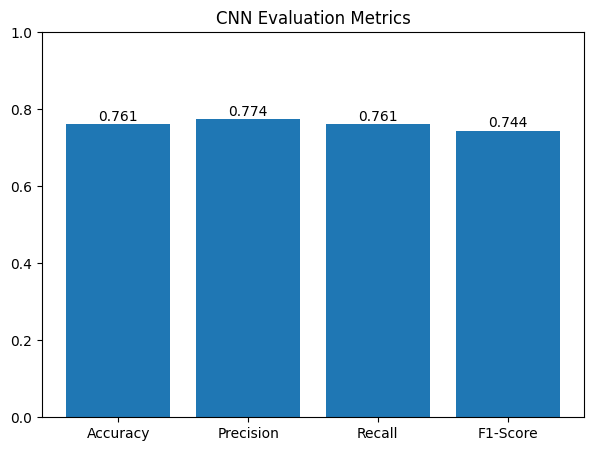

In [ ]:
# ==========================================================
# METRIC VISUALIZATION
# ==========================================================

plt.figure(figsize=(7,5))

bars = plt.bar(
    cnn_result["Metric"],
    cnn_result["Score"]
)

plt.ylim(0,1)

plt.title("CNN Evaluation Metrics")

for bar in bars:

    y = bar.get_height()

    plt.text(
        bar.get_x()+bar.get_width()/2,
        y+0.01,
        f"{y:.3f}",
        ha="center"
    )

plt.show()

# 🚀 16. Modeling - EfficientNetB0

Model kedua menggunakan EfficientNetB0 dengan pendekatan Transfer Learning untuk meningkatkan performa klasifikasi.

In [ ]:
# ==========================================================
# BUILD EFFICIENTNETB0
# ==========================================================

from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model

base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

inputs = Input(shape=(224,224,3))

x = base_model(inputs, training=False)

x = GlobalAveragePooling2D()(x)

x = Dense(256, activation="relu")(x)

x = Dropout(0.5)(x)

outputs = Dense(len(class_names), activation="softmax")(x)

efficientnet_model = Model(inputs, outputs)

efficientnet_model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,378,535 (16.70 MB)

 Trainable params: 328,964 (1.25 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

# ⚙️ 17. Compile EfficientNetB0`

In [ ]:
# ==========================================================
# COMPILE
# ==========================================================

efficientnet_model.compile(

    optimizer=tf.keras.optimizers.Adam(1e-4),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]

)

# 🚀 18. Train EfficientNetB0

In [ ]:
# ==========================================================
# TRAIN
# ==========================================================

checkpoint_eff = tf.keras.callbacks.ModelCheckpoint(
    "best_efficientnet.keras",
    monitor="val_accuracy",
    save_best_only=True
)

history_eff = efficientnet_model.fit(

    train_dataset,

    validation_data=validation_dataset,

    epochs=EPOCHS,

    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint_eff
    ]

)

Epoch 1/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 99s 456ms/step - accuracy: 0.2538 - loss: 1.4022 - val_accuracy: 0.2321 - val_loss: 1.3899 - learning_rate: 1.0000e-04
Epoch 2/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 55s 393ms/step - accuracy: 0.2574 - loss: 1.3924 - val_accuracy: 0.2330 - val_loss: 1.3885 - learning_rate: 1.0000e-04
Epoch 3/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 82s 393ms/step - accuracy: 0.2536 - loss: 1.3894 - val_accuracy: 0.2321 - val_loss: 1.3895 - learning_rate: 1.0000e-04
Epoch 4/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 82s 397ms/step - accuracy: 0.2569 - loss: 1.3888 - val_accuracy: 0.3321 - val_loss: 1.3846 - learning_rate: 2.0000e-05
Epoch 5/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 55s 385ms/step - accuracy: 0.2609 - loss: 1.3874 - val_accuracy: 0.2991 - val_loss: 1.3847 - learning_rate: 2.0000e-05


# 📈 19. Training Result

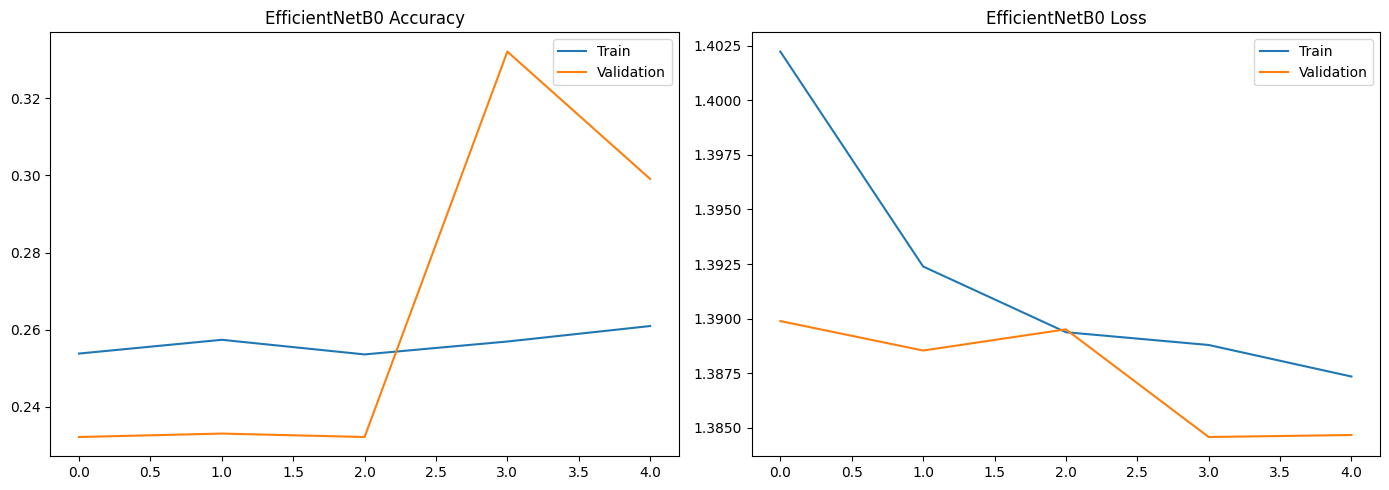

In [ ]:
# ==========================================================
# ACCURACY & LOSS
# ==========================================================

plt.figure(figsize=(14,5))

plt.subplot(1,2,1)

plt.plot(history_eff.history["accuracy"], label="Train")
plt.plot(history_eff.history["val_accuracy"], label="Validation")

plt.title("EfficientNetB0 Accuracy")

plt.legend()

plt.subplot(1,2,2)

plt.plot(history_eff.history["loss"], label="Train")
plt.plot(history_eff.history["val_loss"], label="Validation")

plt.title("EfficientNetB0 Loss")

plt.legend()

plt.tight_layout()

plt.show()

# 📊 20. Evaluation - EfficientNetB0

In [ ]:
# ==========================================================
# PREDICTION
# ==========================================================

y_prob_eff = efficientnet_model.predict(test_dataset)

y_pred_eff = np.argmax(y_prob_eff, axis=1)

eff_accuracy = accuracy_score(y_true, y_pred_eff)

eff_precision = precision_score(
    y_true,
    y_pred_eff,
    average="weighted"
)

eff_recall = recall_score(
    y_true,
    y_pred_eff,
    average="weighted"
)

eff_f1 = f1_score(
    y_true,
    y_pred_eff,
    average="weighted"
)

print("Accuracy :", eff_accuracy)
print("Precision :", eff_precision)
print("Recall :", eff_recall)
print("F1 :", eff_f1)

print(classification_report(
    y_true,
    y_pred_eff,
    target_names=class_names
))

50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 43ms/step
Accuracy : 0.25
Precision : 0.0625
Recall : 0.25
F1 : 0.1
              precision    recall  f1-score   support

      glioma       0.25      1.00      0.40       400
  meningioma       0.00      0.00      0.00       400
     notumor       0.00      0.00      0.00       400
   pituitary       0.00      0.00      0.00       400

    accuracy                           0.25      1600
   macro avg       0.06      0.25      0.10      1600
weighted avg       0.06      0.25      0.10      1600



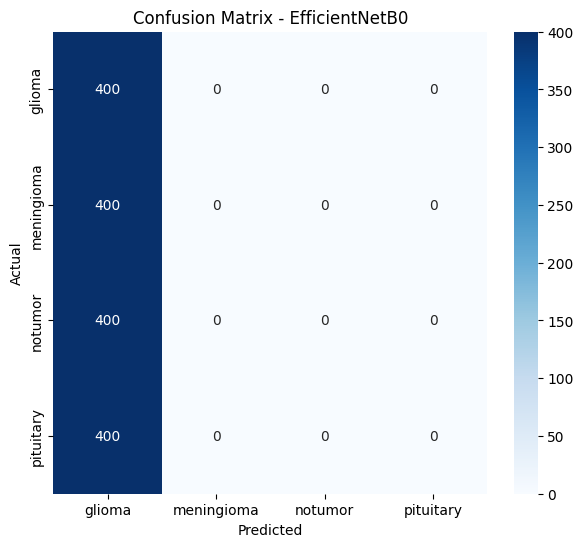

In [ ]:
# ==========================================================
# CONFUSION MATRIX
# ==========================================================

cm = confusion_matrix(y_true, y_pred_eff)

plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix - EfficientNetB0")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

# 🔧 21. Fine Tuning

Membuka beberapa layer terakhir EfficientNetB0 untuk meningkatkan performa model.

In [ ]:
# ==========================================================
# FINE TUNING
# ==========================================================

base_model.trainable = True

fine_tune_at = 200

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

efficientnet_model.compile(

    optimizer=tf.keras.optimizers.Adam(1e-5),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]

)

history_fine = efficientnet_model.fit(

    train_dataset,

    validation_data=validation_dataset,

    epochs=10,

    callbacks=[
        early_stop,
        reduce_lr
    ]

)

Epoch 1/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 105s 440ms/step - accuracy: 0.2701 - loss: 1.4045 - val_accuracy: 0.2321 - val_loss: 1.3980 - learning_rate: 1.0000e-05
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 55s 389ms/step - accuracy: 0.2835 - loss: 1.3915 - val_accuracy: 0.2339 - val_loss: 1.3882 - learning_rate: 1.0000e-05
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 55s 391ms/step - accuracy: 0.3022 - loss: 1.3812 - val_accuracy: 0.5634 - val_loss: 1.3727 - learning_rate: 1.0000e-05
Epoch 4/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 82s 397ms/step - accuracy: 0.3047 - loss: 1.3774 - val_accuracy: 0.4420 - val_loss: 1.3632 - learning_rate: 2.0000e-06
Epoch 5/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 55s 390ms/step - accuracy: 0.3109 - loss: 1.3721 - val_accuracy: 0.4661 - val_loss: 1.3585 - learning_rate: 2.0000e-06


# 📈 22. Fine Tuning Result

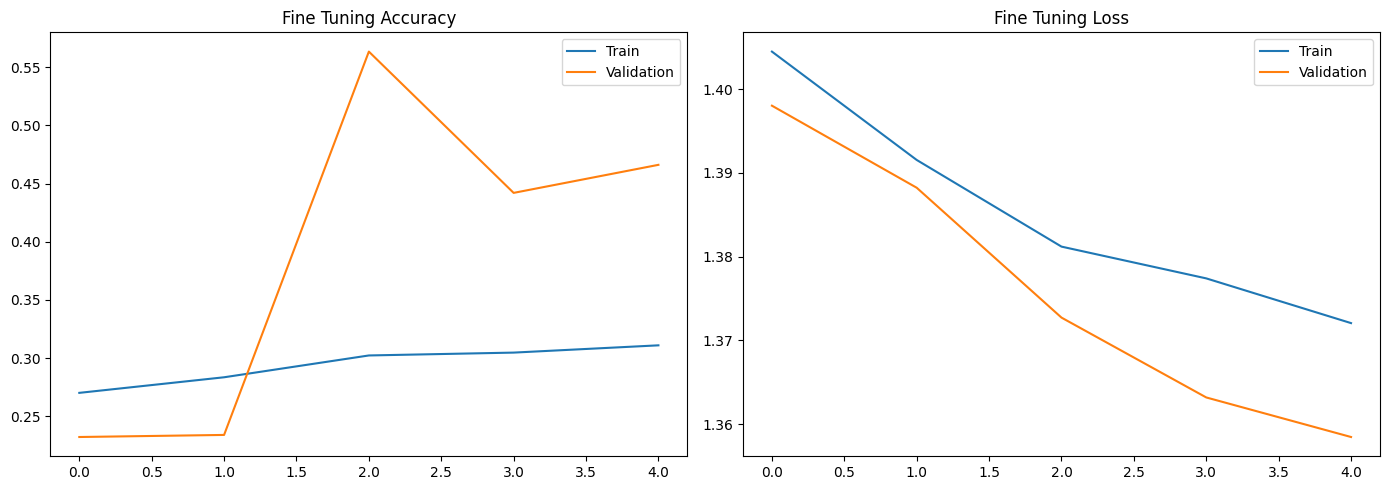

In [ ]:
# ==========================================================
# FINE TUNING RESULT
# ==========================================================

plt.figure(figsize=(14,5))

plt.subplot(1,2,1)

plt.plot(history_fine.history["accuracy"], label="Train")
plt.plot(history_fine.history["val_accuracy"], label="Validation")

plt.title("Fine Tuning Accuracy")
plt.legend()

plt.subplot(1,2,2)

plt.plot(history_fine.history["loss"], label="Train")
plt.plot(history_fine.history["val_loss"], label="Validation")

plt.title("Fine Tuning Loss")
plt.legend()

plt.tight_layout()

plt.show()

# 📊 23. Model Comparison

In [ ]:
# ==========================================================
# MODEL COMPARISON
# ==========================================================

comparison = pd.DataFrame({

    "Model":[
        "Custom CNN",
        "EfficientNetB0"
    ],

    "Accuracy":[
        cnn_accuracy,
        eff_accuracy
    ],

    "Precision":[
        cnn_precision,
        eff_precision
    ],

    "Recall":[
        cnn_recall,
        eff_recall
    ],

    "F1-Score":[
        cnn_f1,
        eff_f1
    ]

})

display(comparison)

,Model,Accuracy,Precision,Recall,F1-Score
0,Custom CNN,0.760625,0.773945,0.760625,0.743834
1,EfficientNetB0,0.250000,0.062500,0.250000,0.100000


In [ ]:
# ==========================================================
# SELECT BEST MODEL
# ==========================================================

if cnn_accuracy >= eff_accuracy:
    best_model = cnn_model
    best_model_name = "Custom CNN"
else:
    best_model = efficientnet_model
    best_model_name = "EfficientNetB0"

print(f"Best Model : {best_model_name}")

Best Model : Custom CNN


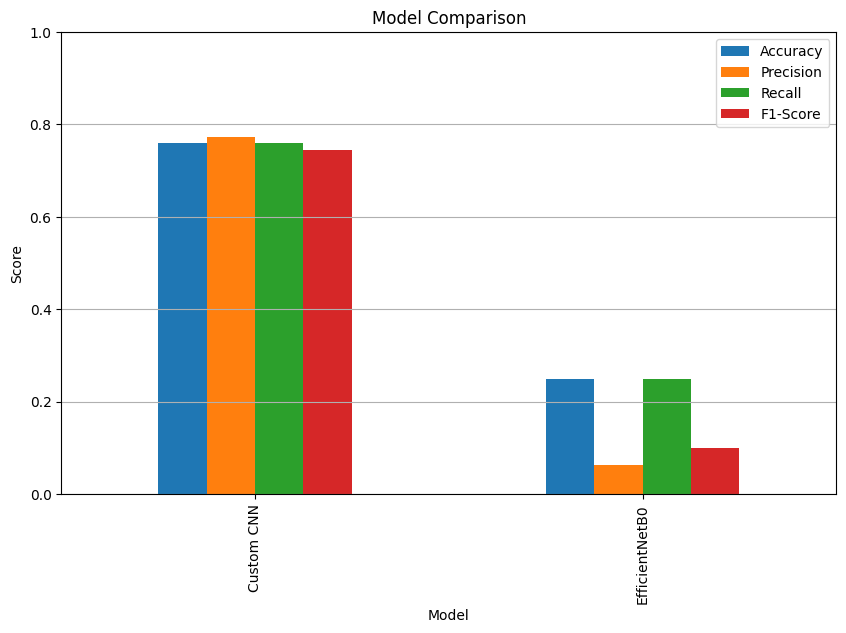

In [ ]:
# ==========================================================
# COMPARISON CHART
# ==========================================================

comparison.set_index("Model").plot(
    kind="bar",
    figsize=(10,6)
)

plt.ylim(0,1)

plt.ylabel("Score")

plt.title("Model Comparison")

plt.grid(axis="y")

plt.show()

# 🖼️ 24. Real Testing

In [ ]:
# ==========================================================
# UPLOAD IMAGE
# ==========================================================

uploaded = files.upload()

image_path = list(uploaded.keys())[0]

Saving Screenshot 2026-07-12 203051.png to Screenshot 2026-07-12 203051.png


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step


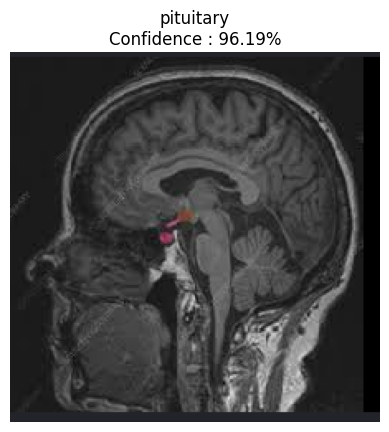

In [ ]:
# ==========================================================
# PREDICT IMAGE
# ==========================================================

from tensorflow.keras.preprocessing import image

img = image.load_img(
    image_path,
    target_size=(224,224)
)

img_array = image.img_to_array(img)

img_array = img_array/255.0

img_array = np.expand_dims(img_array,axis=0)

prediction = best_model.predict(img_array)

predicted_class = class_names[np.argmax(prediction)]

confidence = np.max(prediction)*100

plt.imshow(img)

plt.axis("off")

plt.title(
    f"{predicted_class}\nConfidence : {confidence:.2f}%"
)

plt.show()

,Class,Probability
0,glioma,0.000664
1,meningioma,0.006764
2,notumor,0.030715
3,pituitary,0.961857


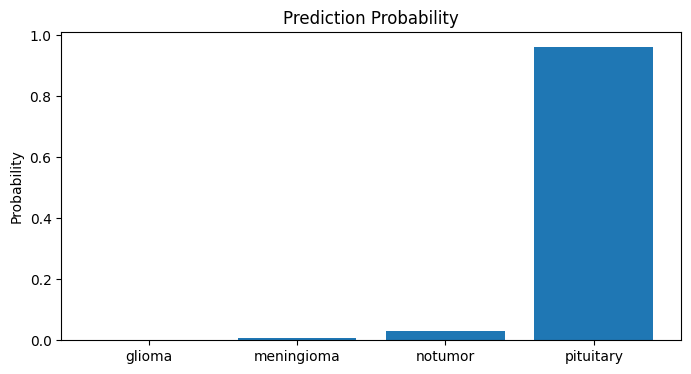

In [ ]:
# ==========================================================
# PROBABILITY
# ==========================================================

prob = pd.DataFrame({

    "Class":class_names,

    "Probability":prediction[0]

})

display(prob)

plt.figure(figsize=(8,4))

plt.bar(
    prob["Class"],
    prob["Probability"]
)

plt.title("Prediction Probability")

plt.ylabel("Probability")

plt.show()

# 💾 25. Save Model

In [ ]:
# ==========================================================
# SAVE MODEL
# ==========================================================

import json

# Simpan model CNN sebagai model final
cnn_model.save("brain_tumor_model.keras")

with open("class_names.json", "w") as f:
    json.dump(class_names, f)

print("="*50)
print("✅ Final Model : Custom CNN")
print("✅ Model berhasil disimpan.")
print("📁 brain_tumor_model.keras")
print("📁 class_names.json")
print("="*50)

✅ Final Model : Custom CNN
✅ Model berhasil disimpan.
📁 brain_tumor_model.keras
📁 class_names.json


# 📁 Save Visualization

Menyimpan seluruh hasil visualisasi yang akan digunakan pada aplikasi Flask.

In [ ]:
# ==========================================================
# EXPORT ALL FIGURES FOR FLASK
# ==========================================================

import os
import shutil
from google.colab import files

SAVE_DIR = "/content/flask_images"
os.makedirs(SAVE_DIR, exist_ok=True)

# ---------- Dataset Distribution ----------
plt.figure(figsize=(8,5))
bars = plt.bar(dataset_info["Class"], dataset_info["Total"])

plt.title("Dataset Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")

for bar in bars:
    h = bar.get_height()
    plt.text(
        bar.get_x()+bar.get_width()/2,
        h+10,
        int(h),
        ha="center"
    )

plt.savefig(
    os.path.join(SAVE_DIR,"dataset_distribution.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.close()

# ---------- Sample Images ----------
plt.figure(figsize=(12,8))

for i, cls in enumerate(class_names):

    folder = os.path.join(TRAIN_DIR, cls)

    image = random.choice(os.listdir(folder))

    img = mpimg.imread(os.path.join(folder,image))

    plt.subplot(2,2,i+1)

    plt.imshow(img)

    plt.title(cls)

    plt.axis("off")

plt.tight_layout()

plt.savefig(
    os.path.join(SAVE_DIR,"sample_images.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.close()

# ---------- CNN Accuracy & Loss ----------
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(history_cnn.history["accuracy"],label="Train")
plt.plot(history_cnn.history["val_accuracy"],label="Validation")
plt.title("CNN Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_cnn.history["loss"],label="Train")
plt.plot(history_cnn.history["val_loss"],label="Validation")
plt.title("CNN Loss")
plt.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(SAVE_DIR,"cnn_accuracy_loss.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.close()

# ---------- CNN Confusion Matrix ----------
plt.figure(figsize=(7,6))

sns.heatmap(
    confusion_matrix(y_true,y_pred),
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("CNN Confusion Matrix")

plt.savefig(
    os.path.join(SAVE_DIR,"cnn_confusion_matrix.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.close()

# ---------- EfficientNet Accuracy & Loss ----------
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(history_eff.history["accuracy"],label="Train")
plt.plot(history_eff.history["val_accuracy"],label="Validation")
plt.title("EfficientNet Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_eff.history["loss"],label="Train")
plt.plot(history_eff.history["val_loss"],label="Validation")
plt.title("EfficientNet Loss")
plt.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(SAVE_DIR,"efficientnet_accuracy_loss.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.close()

# ---------- EfficientNet Confusion Matrix ----------
plt.figure(figsize=(7,6))

sns.heatmap(
    confusion_matrix(y_true,y_pred_eff),
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("EfficientNet Confusion Matrix")

plt.savefig(
    os.path.join(SAVE_DIR,"efficientnet_confusion_matrix.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.close()

# ---------- Model Comparison ----------
comparison.set_index("Model").plot(
    kind="bar",
    figsize=(10,6)
)

plt.ylim(0,1)
plt.ylabel("Score")
plt.title("Model Comparison")
plt.grid(axis="y")

plt.savefig(
    os.path.join(SAVE_DIR,"model_comparison.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.close()

# ---------- Prediction Probability ----------
plt.figure(figsize=(8,4))

plt.bar(
    prob["Class"],
    prob["Probability"]
)

plt.title("Prediction Probability")

plt.ylabel("Probability")

plt.savefig(
    os.path.join(SAVE_DIR,"prediction_probability.png"),
    dpi=300,
    bbox_inches="tight"
)
plt.close()

# ---------- ZIP ----------
shutil.make_archive(
    "/content/flask_images",
    "zip",
    SAVE_DIR
)

print("="*60)
print("✅ Semua gambar berhasil diekspor.")
print("📁 Folder :", SAVE_DIR)
print("📦 File   : flask_images.zip")
print("="*60)

files.download("/content/flask_images.zip")

✅ Semua gambar berhasil diekspor.
📁 Folder : /content/flask_images
📦 File   : flask_images.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>